In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/shelter_outcomes.csv")
print(df.shape)
df.head()

In [ ]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== TIPOS DE DADOS ===")
print(df.columns.tolist())

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

=== SHAPE ===
(173775, 12)

=== TIPOS DE DADOS ===
['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']

=== VALORES NULOS ===
Animal ID               0
Date of Birth           0
Name                49784
DateTime                0
MonthYear               0
Outcome Type           46
Outcome Subtype     94115
Animal Type             0
Sex upon Outcome        1
Age upon Outcome        9
Breed                   0
Color                   0
dtype: int64


In [ ]:
# Distribuição dos desfechos - nossa variável alvo
print("=== DISTRIBUIÇÃO DE OUTCOME TYPE ===")
print(df["Outcome Type"].value_counts())
print("\n=== PERCENTUAL ===")
print(df["Outcome Type"].value_counts(normalize=True).mul(100).round(2))

=== DISTRIBUIÇÃO DE OUTCOME TYPE ===
Outcome Type
Adoption           84598
Transfer           48689
Return to Owner    25691
Euthanasia         10833
Died                1672
Rto-Adopt           1241
Disposal             877
Missing               92
Relocate              29
Stolen                 5
Lost                   2
Name: count, dtype: int64

=== PERCENTUAL ===
Outcome Type
Adoption           48.70
Transfer           28.03
Return to Owner    14.79
Euthanasia          6.24
Died                0.96
Rto-Adopt           0.71
Disposal            0.50
Missing             0.05
Relocate            0.02
Stolen              0.00
Lost                0.00
Name: proportion, dtype: float64


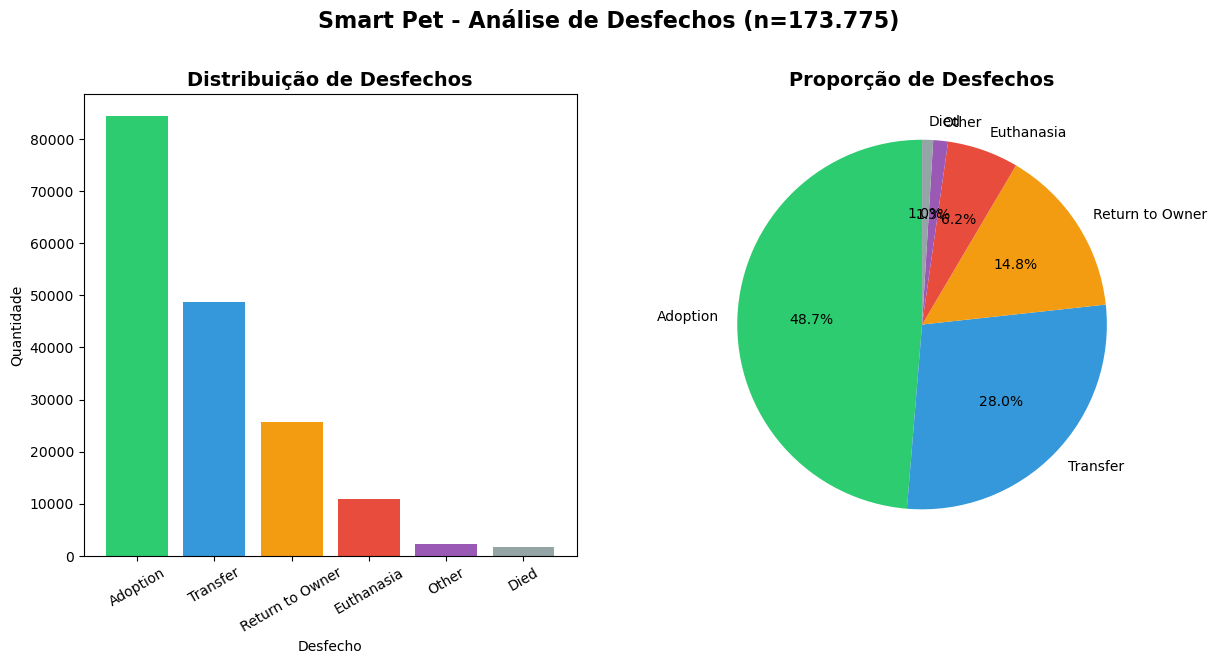

Gráfico salvo em docs/architecture/


In [ ]:
# Agrupar por categorias
outcome_map = {
    "Adoption": "Adoption",
    "Transfer": "Transfer",
    "Return to Owner": "Return to Owner",
    "Euthanasia": "Euthanasia",
    "Died": "Died",
    "Rto-Adopt": "Other",
    "Disposal": "Other",
    "Missing": "Other",
    "Relocate": "Other",
    "Stolen": "Other",
    "lost": "Other"
}

df["Outcome Group"] = df["Outcome Type"].map(outcome_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1 - Contagem
counts = df["Outcome Group"].value_counts()
colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c", "#9b59b6", "#95a5a6",]
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Distribuição de Desfechos", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Desfecho")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=30)

# Gráfico 2 - Percentual (pizza)
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Proporção de Desfechos", fontsize=14, fontweight="bold")

plt.suptitle("Smart Pet - Análise de Desfechos (n=173.775)", fontsize=16, fontweight="bold", y=1.02)
plt.savefig("../docs/architecture/eda_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo em docs/architecture/")

=== TIPOS DE ANIMAIS ===
Animal Type
Dog          94505
Cat          69399
Other         8960
Bird           877
Livestock       34
Name: count, dtype: int64


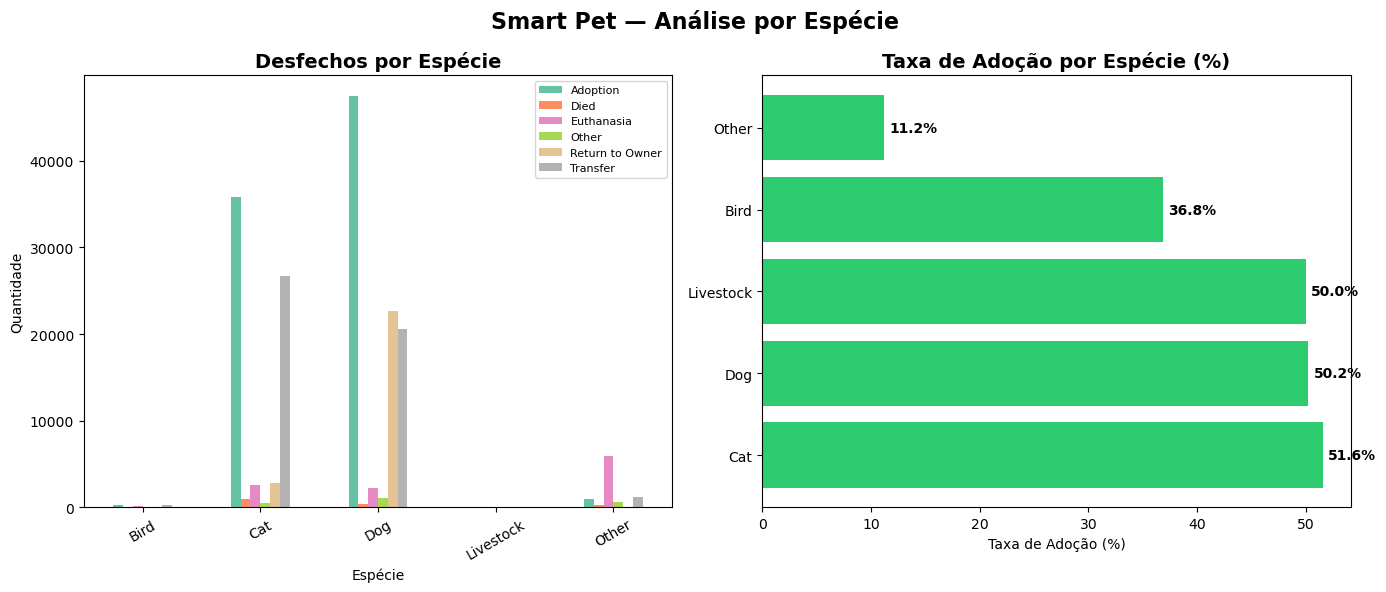

In [ ]:
# Distribuição por tipo de animal
print("=== TIPOS DE ANIMAIS ===")
print(df["Animal Type"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1 — Desfechos por espécie
species_outcome = df.groupby(["Animal Type", "Outcome Group"]).size().unstack(fill_value=0)
species_outcome.plot(kind="bar", ax=axes[0], colormap="Set2")
axes[0].set_title("Desfechos por Espécie", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Espécie")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(loc="upper right", fontsize=8)

# Gráfico 2 — Taxa de adoção por espécie
adoption_rate = df.groupby("Animal Type").apply(
    lambda x: (x["Outcome Group"] == "Adoption").sum() / len(x) * 100
).sort_values(ascending=False)

axes[1].barh(adoption_rate.index, adoption_rate.values, color="#2ecc71")
axes[1].set_title("Taxa de Adoção por Espécie (%)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Taxa de Adoção (%)")
for i, v in enumerate(adoption_rate.values):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.suptitle("Smart Pet — Análise por Espécie", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/architecture/eda_species.png", dpi=150, bbox_inches="tight")
plt.show()

=== IDADE (anos) ===
count    173766.00
mean          1.98
std           2.80
min          -4.00
25%           0.16
50%           1.00
75%           2.00
max          30.00
Name: Age in Years, dtype: float64


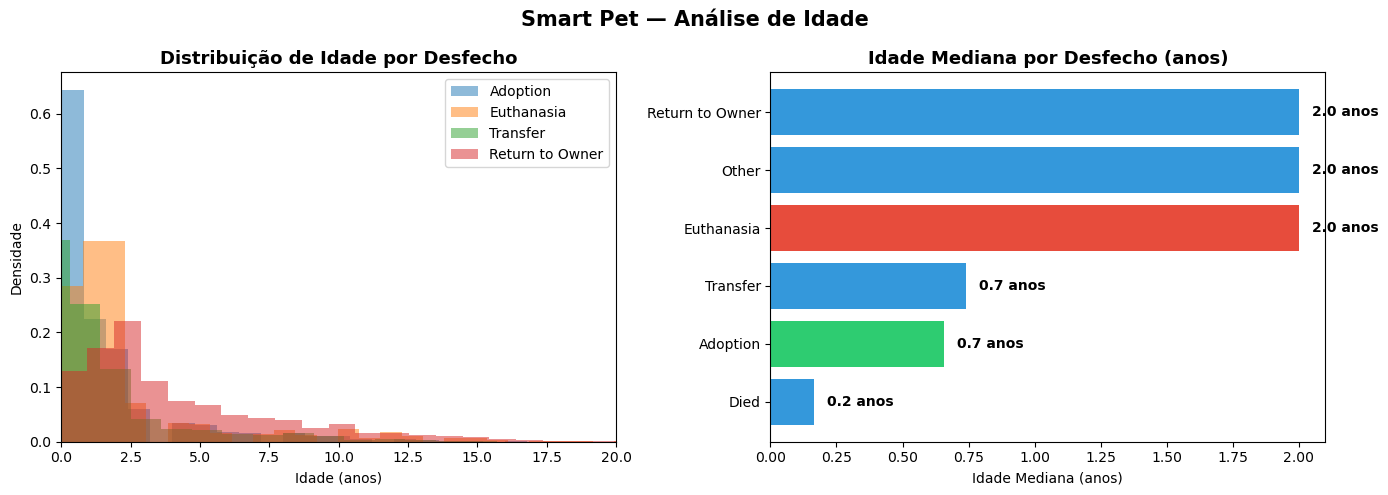

In [ ]:
# Converter idade para número de dias
def parse_age(age_str):
    if pd.isna(age_str):
        return np.nan
    age_str = str(age_str).lower().strip()
    try:
        num = int(age_str.split()[0])
        if 'year'  in age_str: return num * 365
        if 'month' in age_str: return num * 30
        if 'week'  in age_str: return num * 7
        if 'day'   in age_str: return num
    except:
        return np.nan
    return np.nan

df['Age in Days'] = df['Age upon Outcome'].apply(parse_age)
df['Age in Years'] = df['Age in Days'] / 365

print("=== IDADE (anos) ===")
print(df['Age in Years'].describe().round(2))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Distribuição de idade por desfecho
for outcome in ['Adoption', 'Euthanasia', 'Transfer', 'Return to Owner']:
    subset = df[df['Outcome Group'] == outcome]['Age in Years'].dropna()
    axes[0].hist(subset, bins=30, alpha=0.5, label=outcome, density=True)
axes[0].set_title('Distribuição de Idade por Desfecho', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Densidade')
axes[0].set_xlim(0, 20)
axes[0].legend()

# Gráfico 2 — Idade média por desfecho
age_by_outcome = df.groupby('Outcome Group')['Age in Years'].median().sort_values()
colors = ['#e74c3c' if x == 'Euthanasia' else '#2ecc71' if x == 'Adoption' else '#3498db' 
          for x in age_by_outcome.index]
axes[1].barh(age_by_outcome.index, age_by_outcome.values, color=colors)
axes[1].set_title('Idade Mediana por Desfecho (anos)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Idade Mediana (anos)')
for i, v in enumerate(age_by_outcome.values):
    axes[1].text(v + 0.05, i, f'{v:.1f} anos', va='center', fontweight='bold')

plt.suptitle('Smart Pet — Análise de Idade', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/architecture/eda_age.png', dpi=150, bbox_inches='tight')
plt.show()

**1. Animais adotados são jovens** — mediana de 0.7 anos. Filhotes saem muito mais rápido

**2. Eutanásia acontece em animais mais velhos** — mediana de 2.0 anos, quase 3x mais que adoção. Idade é uma feature poderosa para o modelo de risco

**3. "Died" tem mediana de 0.2 anos** — animais que morrem no abrigo são muito jovens, provavelmente por doenças

=== SEX UPON OUTCOME ===
Sex upon Outcome
Neutered Male    60933
Spayed Female    55269
Intact Male      22263
Intact Female    21804
Unknown          13505
Name: count, dtype: int64


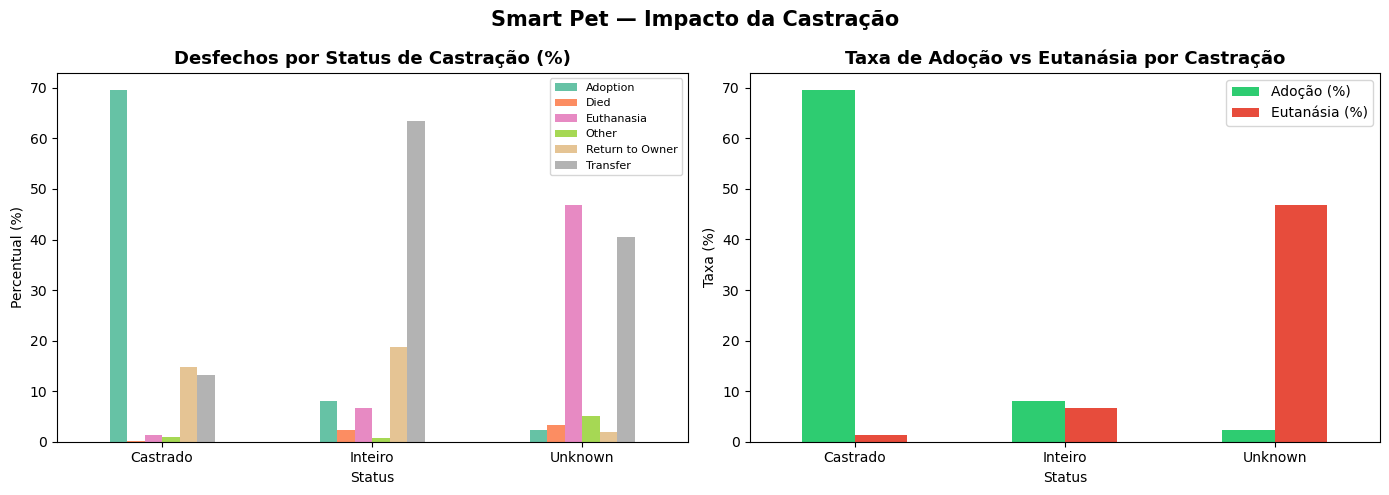

In [ ]:
# Análise de castração
print("=== SEX UPON OUTCOME ===")
print(df['Sex upon Outcome'].value_counts())

# Criar feature de castração
def parse_sex(val):
    if pd.isna(val): return 'Unknown'
    val = str(val).lower()
    if 'neutered' in val or 'spayed' in val: return 'Castrado'
    if 'intact'   in val:                    return 'Inteiro'
    return 'Unknown'

df['Castration Status'] = df['Sex upon Outcome'].apply(parse_sex)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Desfecho por status de castração
cast_outcome = df.groupby(['Castration Status', 'Outcome Group']).size().unstack(fill_value=0)
cast_outcome_pct = cast_outcome.div(cast_outcome.sum(axis=1), axis=0) * 100
cast_outcome_pct.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Desfechos por Status de Castração (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Percentual (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper right', fontsize=8)

# Gráfico 2 — Taxa de adoção vs eutanásia por castração
metrics = pd.DataFrame({
    'Adoção (%)':    df.groupby('Castration Status').apply(lambda x: (x['Outcome Group'] == 'Adoption').mean() * 100),
    'Eutanásia (%)': df.groupby('Castration Status').apply(lambda x: (x['Outcome Group'] == 'Euthanasia').mean() * 100),
})
metrics.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Taxa de Adoção vs Eutanásia por Castração', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Taxa (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.suptitle('Smart Pet — Impacto da Castração', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/architecture/eda_castration.png', dpi=150, bbox_inches='tight')
plt.show()

**3 insights críticos:**

**1. Castrados são adotados 70% das vezes** — a feature mais preditiva do dataset até agora

**2. Inteiros têm apenas 8% de adoção** — e 6% de eutanásia, quase igual aos castrados

**3. "Unknown" tem 48% de eutanásia** — animais sem identificação de sexo são os mais vulneráveis. Provavelmente animais em estado crítico quando chegam ao abrigo

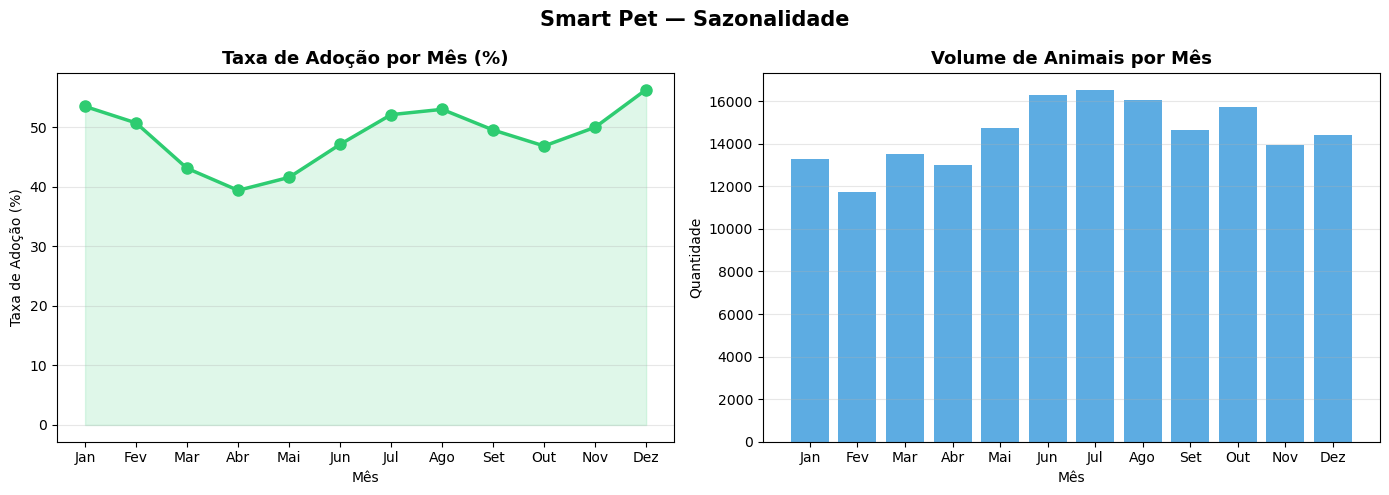

In [ ]:
# Extrair mês e ano
df['DateTime'] = pd.to_datetime(df['DateTime'], format='mixed', utc=True)
df['Month'] = df['DateTime'].dt.month
df['Year']  = df['DateTime'].dt.year

# Taxa de adoção por mês
monthly = df.groupby('Month').apply(
    lambda x: (x['Outcome Group'] == 'Adoption').mean() * 100
).reset_index()
monthly.columns = ['Month', 'Adoption Rate']

month_names = ['Jan','Fev','Mar','Abr','Mai','Jun',
               'Jul','Ago','Set','Out','Nov','Dez']
monthly['Month Name'] = monthly['Month'].apply(lambda x: month_names[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Taxa de adoção por mês
axes[0].plot(monthly['Month Name'], monthly['Adoption Rate'],
             marker='o', linewidth=2.5, color='#2ecc71', markersize=8)
axes[0].fill_between(range(12), monthly['Adoption Rate'],
                     alpha=0.15, color='#2ecc71')
axes[0].set_title('Taxa de Adoção por Mês (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Taxa de Adoção (%)')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(monthly['Month Name'])
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2 — Volume de entradas por mês
monthly_volume = df.groupby('Month').size().reset_index()
monthly_volume.columns = ['Month', 'Total']
monthly_volume['Month Name'] = monthly_volume['Month'].apply(lambda x: month_names[x-1])

axes[1].bar(monthly_volume['Month Name'], monthly_volume['Total'],
            color='#3498db', alpha=0.8)
axes[1].set_title('Volume de Animais por Mês', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Quantidade')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Smart Pet — Sazonalidade', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/architecture/eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

🎉 Dois insights importantes aqui:

**1. Março e Abril têm queda na adoção** — caindo para ~40%. Período pós-festas, menos movimento nos abrigos

**2. Junho a Agosto têm o maior volume de animais** — provavelmente filhotes nascidos na primavera chegando nos abrigos

In [ ]:
# As 10 cores mais comuns
print(df['Color'].value_counts().head(10))

Color
Black/White          17999
Black                14681
Brown Tabby          10701
Brown                 7151
White                 6132
Brown/White           5571
Brown Tabby/White     5465
Orange Tabby          5149
Tan/White             4971
White/Black           4820
Name: count, dtype: int64


In [ ]:
# Taxa de adoção por cor
color_adoption = df.groupby('Color').apply(
    lambda x: (x['Outcome Group'] == 'Adoption').mean() * 100
).sort_values(ascending=False)

print("=== TOP 10 CORES COM MAIOR ADOÇÃO ===")
print(color_adoption.head(10).round(2))

print("\n=== TOP 10 CORES COM MENOR ADOÇÃO ===")
print(color_adoption.tail(10).round(2))

print(f"\nTotal de cores únicas: {df['Color'].nunique()}")

=== TOP 10 CORES COM MAIOR ADOÇÃO ===
Color
Blue Merle/Brown Merle    100.0
Blue Merle/Cream          100.0
Blue Tabby/Tan            100.0
Agouti/Brown Tabby        100.0
Blue Tabby/Brown          100.0
Gray Tabby/Orange         100.0
Blue Smoke/Tan            100.0
Blue Smoke/Gray           100.0
Gray Tabby/Tan            100.0
Gray/Calico               100.0
dtype: float64

=== TOP 10 CORES COM MENOR ADOÇÃO ===
Color
Orange/Blue                  0.0
Orange/Cream                 0.0
Red Merle/Blue Merle         0.0
Red Merle/Brown Merle        0.0
Red Merle/Red Merle          0.0
Red Merle/Tan                0.0
Red Merle/Tricolor           0.0
Black/Tortie                 0.0
Red Tick/Blue                0.0
Orange Tabby/Tortie Point    0.0
dtype: float64

Total de cores únicas: 663
